In [1]:
# !pip3 install scikit-learn matplotlib numpy

In [2]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt 
import numpy as np 
import random 
%matplotlib inline

In [3]:
np.random.seed(1337)
random.seed(1337)

In [4]:
from micrograd.engine import Value 
from micrograd.nn import MLP, Layer, Neuron

In [5]:
X, Y = make_moons(n_samples = 100, noise = 0.1)

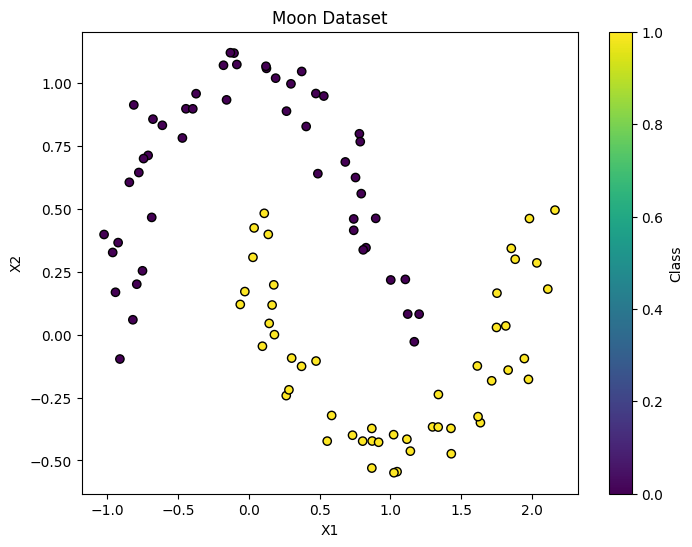

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Moon Dataset')
plt.colorbar(label='Class')
plt.show()

In [7]:
X.dtype

dtype('float64')

In [8]:
type(X)

numpy.ndarray

In [9]:
print(X[:10])

[[ 1.12211461  0.08147717]
 [-0.81882941  0.05879006]
 [ 1.61370966 -0.1246459 ]
 [-0.92300918  0.3652289 ]
 [ 0.14385146  0.04438005]
 [ 0.16447247  0.11738346]
 [ 1.33877062 -0.23800993]
 [ 0.87114861 -0.42271759]
 [ 1.83129946 -0.14104383]
 [ 0.4875712   0.63909283]]


In [10]:
print(Y[:10])

[0 0 1 0 1 1 1 1 1 0]


In [11]:
X.dtype, X[:2], X.shape

(dtype('float64'),
 array([[ 1.12211461,  0.08147717],
        [-0.81882941,  0.05879006]]),
 (100, 2))

In [12]:
Y.dtype, Y[:2], Y.shape

(dtype('int64'), array([0, 0]), (100,))

In [13]:
# x min ? max ? 
X.min(axis = 0), X.max(axis = 0)

(array([-1.02219391, -0.5486393 ]), array([2.16205598, 1.1193894 ]))

In [14]:
# 1st column min value: -1.02 
# 1st column max value: 2.16
# 2nd column min value: -0.54
# 2nd column max value: 1.119

In [15]:
Y.min(), Y.max()

(np.int64(0), np.int64(1))

In [16]:
xs = X.tolist()

In [17]:
len(xs)

100

In [18]:
# for x in xs: 
#     print(x)
#     print(len(x))
#     break
print(len(xs[0]))

2


In [19]:
ys = Y.tolist()

In [20]:
len(ys)

100

In [21]:
type(xs), type(ys)

(list, list)

In [22]:
m = MLP(2, [16, 16, 1])

In [23]:
print(m)

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]


In [24]:
print(len(m.parameters()))

337


In [25]:
ypreds = [m(x) for x in xs]

In [26]:
len(ypreds)

100

In [27]:
import pprint 
pprint.pprint(ypreds[:10])

[Value(data=-0.24267959107182535),
 Value(data=-1.243357473239418),
 Value(data=-0.5369900872329142),
 Value(data=-1.362970378927522),
 Value(data=-0.03684626715837667),
 Value(data=-0.05570888776943643),
 Value(data=-0.5501402258113907),
 Value(data=-0.6642128817124172),
 Value(data=-0.6090788482462419),
 Value(data=-0.3900177892704563)]


In [28]:
import pprint 
pprint.pprint(ys[:10])

[0, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [29]:
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds,  ys))

In [30]:
loss

Value(data=148.1460933434741)

In [31]:
# is 148 loss ok ? 
# initially 50: 0s, 50: 1s
# worst case: -1 predict 
# 1 * 50 + 4 * 50 = 250

In [32]:
for p in m.parameters(): 
    p.grad = 0.0

In [33]:
loss.backward()

In [34]:
for p in m.parameters():
    p.data += (-0.0001) * p.grad

In [35]:
ypreds = [m(x) for x in xs]

In [36]:
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds,  ys))

In [37]:
loss

Value(data=47.111046882923)

In [38]:
# what is an epoch ? 
# number of times your neural network sees the entire dataset

In [39]:
len(xs)

100

In [40]:
r_indx = random.sample(range(len(xs)), 50)

In [41]:
len(r_indx)

50

In [42]:
print(r_indx[:10])

[27, 20, 76, 60, 34, 69, 10, 86, 35, 61]


In [ ]:
epoch = 16000
for i in range(epoch): 
    r_indx = random.sample(range(len(xs)), 50)
    batch_xs = [xs[x]for x in r_indx]
    batch_ys = [ys[x] for x in r_indx]

    ypreds = [m(x) for x in batch_xs]
    loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, batch_ys))
    if i % 5 == 0: 
        print("loss: ",loss, "step: ", i)
    for p in m.parameters(): 
        p.grad = 0.0 
    loss.backward()
    for p in m.parameters(): 
        p.data += (-0.00005) * p.grad

loss:  Value(data=20.640081651004923) step:  0
loss:  Value(data=20.958071329910947) step:  5
loss:  Value(data=16.162753671350128) step:  10
loss:  Value(data=15.776296833362649) step:  15
loss:  Value(data=14.179444675155251) step:  20
loss:  Value(data=12.400477096081671) step:  25
loss:  Value(data=11.60129678973097) step:  30
loss:  Value(data=9.411860409590313) step:  35
loss:  Value(data=8.1474289009634) step:  40
loss:  Value(data=8.076811437526985) step:  45
loss:  Value(data=9.312441615424088) step:  50
loss:  Value(data=8.558858734706982) step:  55
loss:  Value(data=6.048161940015125) step:  60
loss:  Value(data=7.0496785470932775) step:  65
loss:  Value(data=7.544088735136335) step:  70
loss:  Value(data=6.263955364511112) step:  75
loss:  Value(data=7.093430535723297) step:  80


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x105b3c970>>
Traceback (most recent call last):
  File "/Users/mac/Desktop/youtube_teaching/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


loss:  Value(data=5.991397558472397) step:  85
loss:  Value(data=4.651774349741044) step:  90
loss:  Value(data=5.197484454712116) step:  95
loss:  Value(data=6.790929726512084) step:  100


In [ ]:
# # Save model weights
# import pickle

# weights = [p.data for p in m.parameters()]
# with open('model_weights_with_batch.pkl', 'wb') as f:
#     pickle.dump(weights, f)

In [43]:
# load model weights 
import pickle
with open("model_weights_with_batch.pkl", 'rb') as f: 
    weights = pickle.load(f)

In [44]:
for p, w in zip(m.parameters(), weights): 
    p.data = w

In [45]:
ypreds = [m(x)for x in xs]
loss = sum((ypred - y) ** 2 for ypred, y in zip(ypreds, ys))


In [46]:
print(loss)

Value(data=0.8544165085367091)


In [47]:
pprint.pprint(ypreds[:10])
pprint.pprint(ys[:10])

[Value(data=0.10783466635045634),
 Value(data=0.08089192299252368),
 Value(data=0.759848092664697),
 Value(data=-0.04633232916464827),
 Value(data=1.0097961521208687),
 Value(data=0.9959439663288054),
 Value(data=0.7954753726230055),
 Value(data=0.9662763015322784),
 Value(data=0.9890503144939758),
 Value(data=0.18799408287245795)]
[0, 0, 1, 0, 1, 1, 1, 1, 1, 0]


(-1.7222875713140988, 2.027712428685901)

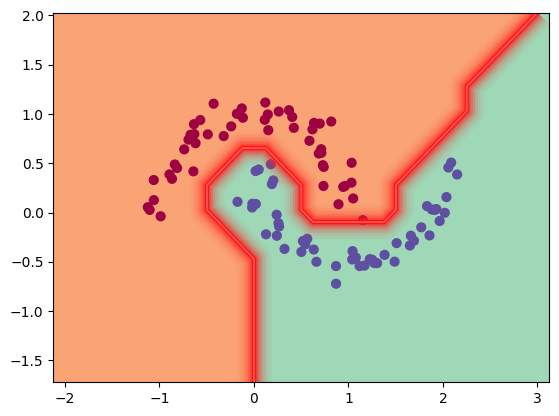

In [48]:
xs2, ys2 = make_moons(n_samples = 100, noise = 0.1)
h = 0.25
x_min, x_max = xs2[:, 0].min() - 1, xs2[:, 0].max() + 1
y_min, y_max = xs2[:, 1].min() - 1, xs2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(m, inputs))
Z = np.array([s.data > 0.5 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# Add glowing neon red decision boundary with enhanced glow
# Outer glow layers (more layers, wider spread, brighter colors)
for lw, alpha in [(25, 0.05), (20, 0.08), (16, 0.12), (12, 0.18), (9, 0.25), (6, 0.35), (4, 0.5)]:
    plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff2222'], linewidths=lw, alpha=alpha)

# Core bright red line
contour = plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff0000'], linewidths=2.5)
# Inner bright highlight
plt.contour(xx, yy, Z, levels=[0.5], colors=['#ff6666'], linewidths=1.5, alpha=0.8)

plt.scatter(xs2[:, 0], xs2[:, 1], c=ys2, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())